<a href="https://colab.research.google.com/github/AdhamAshraf2323/Loan-Predication/blob/master/Bank_Loan_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Loan Eligibility Prediction
**problem**: Manual Evaluation&Time-Consuming Workflow
**Objective:** Automate real-time loan approval decisions using a classification model.

---


## 1. Environment Setup & Data Loading

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i (1).csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Data Understanding


### feature grouping
| Group                 | Features                                                         |
| --------------------- | ---------------------------------------------------------------- |
| **Applicant Profile** | Gender, Married, Dependents, Education, Self_Employed            |
| **Financial Profile** | ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term |
| **Credit Profile**    | Credit_History                                                   |
| **Identifier**        | Loan_ID                                                          |
| **Target Variable**   | Loan_Status                                                      |


In [75]:
df.shape

(614, 13)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [77]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [78]:
missing_values_summary = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(2)
})
missing_values_summary = (missing_values_summary[missing_values_summary["Missing"] > 0]
                          .sort_values(by="Missing", ascending=False))
missing_values_summary

,Missing,Percentage (%)
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


In [79]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [80]:
df.duplicated().sum()

np.int64(0)

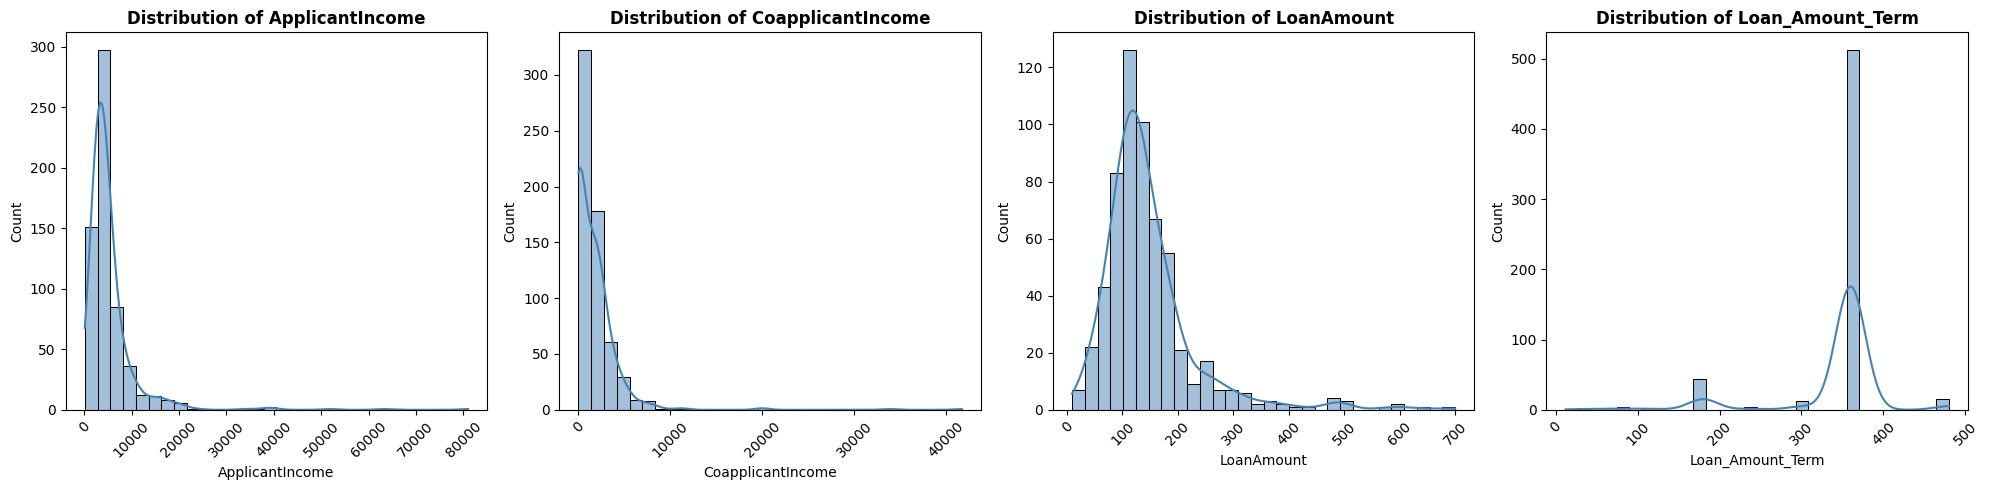

In [81]:

cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# زيادة العرض قليلاً ليتسع لـ 4 رسومات براحة
fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')

    # تدوير الأرقام التلقائية فقط لتجنب تداخلها
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

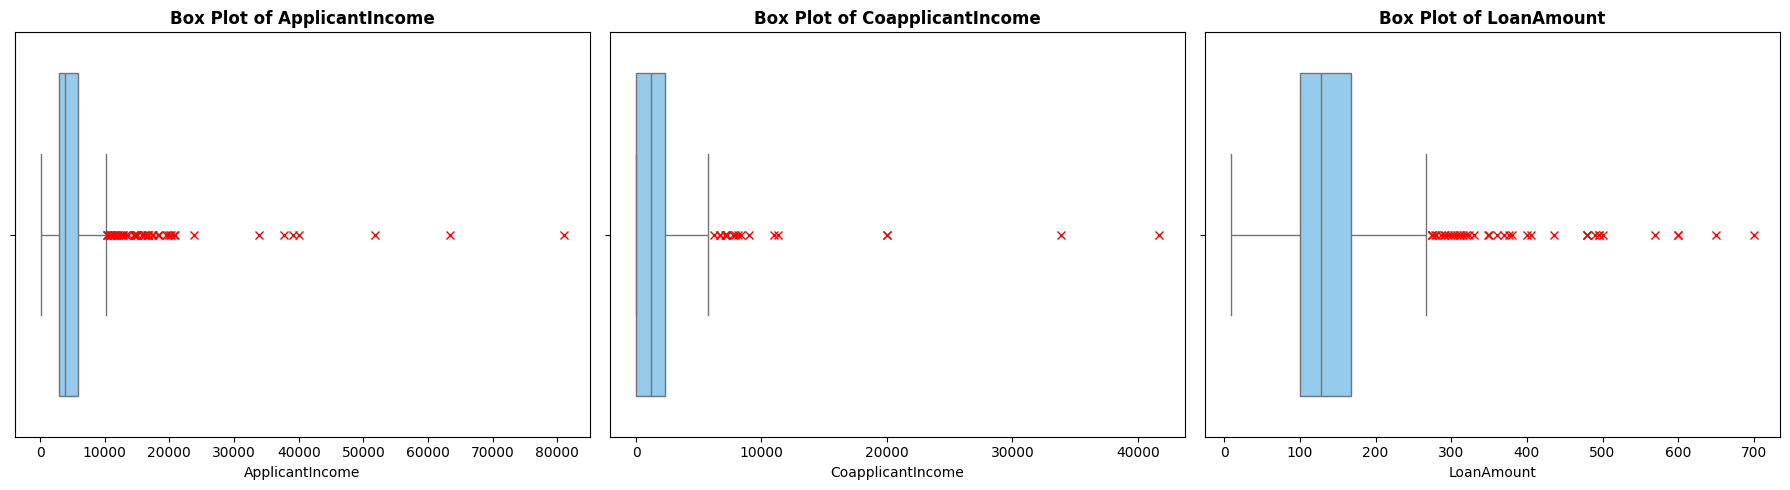

In [82]:

outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 5))

for i, col in enumerate(outlier_cols):
    # رسم الصندوق أفقياً (orient='h') ليكون مريحاً في المقارنة مع الهستوغرام
    sns.boxplot(x=df[col], ax=axes[i], color='lightskyblue', flierprops={"marker": "x", "markeredgecolor": "red"})
    axes[i].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1064/642348673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


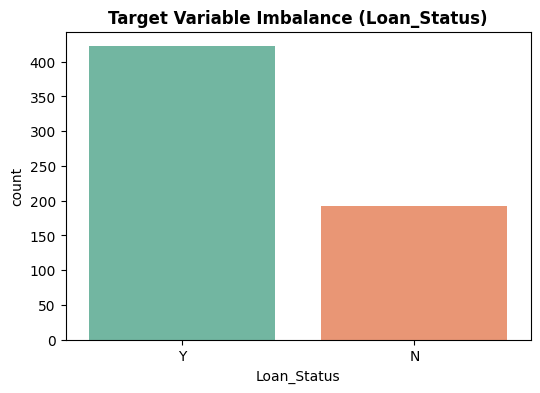

In [83]:

target_pct = df['Loan_Status'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Target Variable Imbalance (Loan_Status)', fontweight='bold')
plt.show()

## 🎯 sprint 1 dleviralbe:
### Findings

- `Loan_ID` is a unique identifier and is not expected to contribute to prediction.
- Missing values exist in `Gender`, `Married`, `Dependents`, and `Self_Employed`.
- `Education` and `Property_Area` contain no missing values.
- **Most applicants are male, married, graduates, and not self-employed.**
- The target variable `(Loan_Status)` is slightly imbalanced toward approved loans.

GO / NO-GO Decision
> 🟢 **Decision: GO**
> **Justification:** The dataset contains sufficient records and logical features to build a baseline predictive model. The identified issues (missing values, skewness, and slight imbalance) are standard data quality problems that can be effectively resolved in the upcoming Data Preparation phase.

## Data Preparation(cleaning&preprocessing)

####handle nulls

In [84]:
df_clean = df.copy()

In [85]:
df_clean['Credit_History'] = (df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0]))

In [86]:
df_clean['Credit_History'].isna().sum()

np.int64(0)

In [87]:
df_clean['Self_Employed'] = (df_clean['Self_Employed'].fillna((df_clean['Self_Employed'].mode()[0])))

In [88]:
df_clean['Self_Employed'].isna().sum()

np.int64(0)

In [89]:
df_clean['LoanAmount'] = (df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median()))

In [90]:
df_clean['LoanAmount'].isna().sum()

np.int64(0)

In [91]:
df_clean['Dependents'] = (df_clean['Dependents'].fillna((df_clean['Dependents'].mode()[0])))

In [92]:
df_clean['Dependents'].isna().sum()

np.int64(0)

In [93]:
df_clean['Gender'] = (df_clean['Gender'].fillna((df_clean['Gender'].mode()[0])))
df_clean['Married'] = (df_clean['Married'].fillna((df_clean['Married'].mode()[0])))
print(df_clean['Married'].isna().sum(),df_clean['Gender'].isna().sum())

0 0


In [94]:
df_clean['Loan_Amount_Term'] = (df_clean['Loan_Amount_Term'].fillna((df_clean['Loan_Amount_Term'].mode()[0])))
df_clean['Loan_Amount_Term'].isna().sum()

np.int64(0)

In [95]:
df_clean.isna().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


####handle outlires

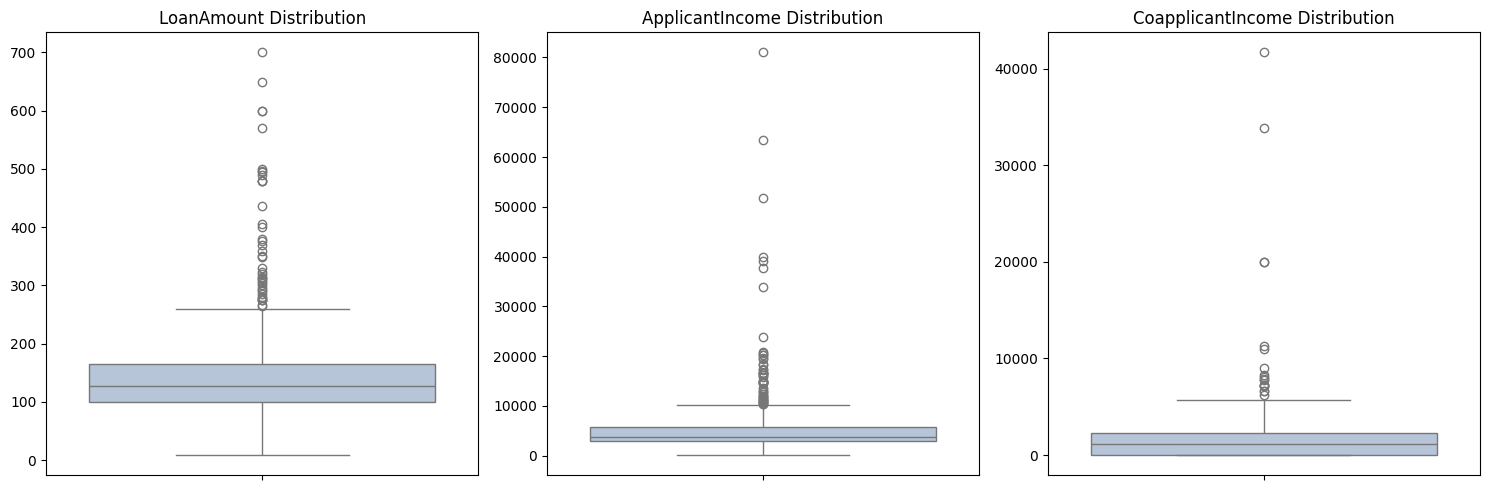

In [96]:

# اختيار الأعمدة الرقمية فقط وتصحيح اسم القائمة
numeric_columns = ['LoanAmount', 'ApplicantIncome','CoapplicantIncome' ]

# إنشاء شبكة رسوم بيانية (صف واحد و 3 أعمدة) لعرضها جنباً إلى جنب
fig, axes = plt.subplots(1, len(numeric_columns), figsize=(15, 5))

# رسم المخططات الصندوقية داخل الشبكة
for i, col in enumerate(numeric_columns):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color='lightsteelblue')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_ylabel('') # إزالة التسمية الجانبية لتنظيف الشكل الجمالي

# ترتيب المسافات بين المخططات تلقائياً
plt.tight_layout()
plt.show()

In [97]:
df_clean['LoanAmount'].describe()

,LoanAmount
count,614.000000
mean,145.752443
std,84.107233
min,9.000000
25%,100.250000
50%,128.000000
75%,164.750000
max,700.000000


In [98]:

Q1_loan = df_clean['LoanAmount'].quantile(0.25)
Q3_loan = df_clean['LoanAmount'].quantile(0.75)

# حساب المدى الربيعي
IQR_loan = Q3_loan - Q1_loan

print(f"IQR for LoanAmount: {IQR_loan}")

# (اختياري) تحديد الحدود الدنيا والعليا لاكتشاف القيم الشاذة
              #100K           64K
lower_bound = Q1_loan - 1.5 * IQR_loan
upper_bound = Q3_loan + 1.5 * IQR_loan
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")

IQR for LoanAmount: 64.5
Lower Bound: 3.5, Upper Bound: 261.5


In [99]:
df_LoanAmount_filtered = df_clean[(df_clean['LoanAmount'] >= lower_bound) &
                                  (df_clean['LoanAmount'] <= upper_bound)].copy()
print(f"عدد الأسطر قبل التصفية: {len(df_clean['LoanAmount'])}")
print(f"عدد الأسطر بعد التصفية: {len(df_LoanAmount_filtered)}")


عدد الأسطر قبل التصفية: 614
عدد الأسطر بعد التصفية: 573


In [100]:
df_LoanAmount_filtered['LoanAmount_Log'] = np.log1p(df_LoanAmount_filtered['LoanAmount'])


print(df_LoanAmount_filtered[['LoanAmount', 'LoanAmount_Log']].head())

   LoanAmount  LoanAmount_Log
0       128.0        4.859812
1       128.0        4.859812
2        66.0        4.204693
3       120.0        4.795791
4       141.0        4.955827


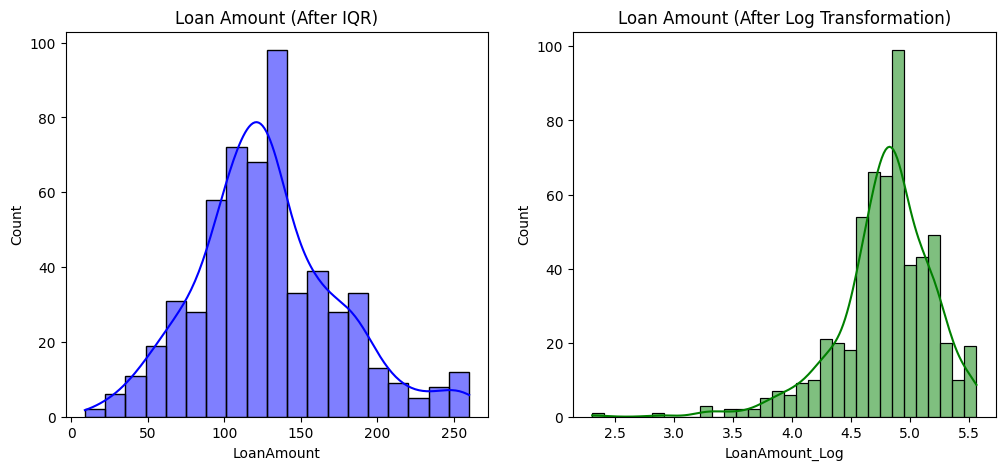

In [101]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# الرسم الأول: البيانات الأصلية (مائلة ومحذوف منها الشاذ بالـ IQR)
sns.histplot(df_LoanAmount_filtered['LoanAmount'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Loan Amount (After IQR)')

# الرسم الثاني: البيانات بعد اللوغاريتم (ستلاحظ أنها أصبحت متماثلة كالجرس)
sns.histplot(df_LoanAmount_filtered['LoanAmount_Log'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Loan Amount (After Log Transformation)')

plt.show()


####Since we will be using a model that assumes a normal distribution, we will omit the logarithmic transformation.

In [102]:
df_LoanAmount_filtered.drop('LoanAmount_Log', axis=1, inplace=True)
df_LoanAmount_filtered.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 🎯 sprint 2 dleviralbe
*   All missing values were successfully identified and handled using appropriate imputation techniques based on each feature's characteristics.

* Numerical features were imputed with statistical measures, while categorical features were filled using the most appropriate category.

*   Outlier analysis was performed on numerical features using the IQR method.

*   Extreme values were treated where necessary to reduce their potential impact on model performance while preserving the overall data distribution.









### **`EDA`**

`H` is shortcut for `hypothesis`

### H1. Does the loan term affect approval?

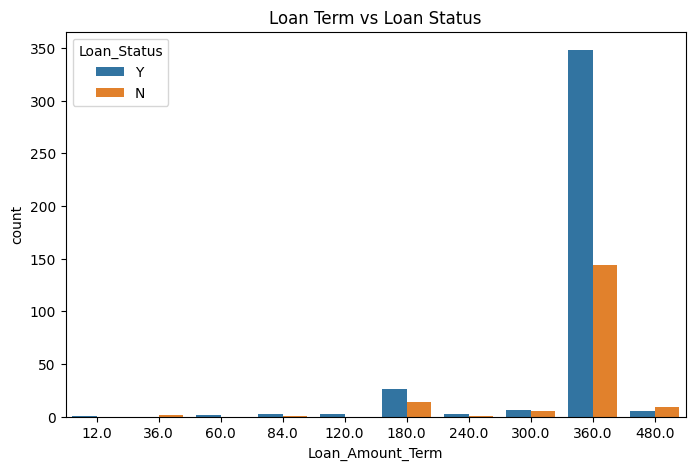

In [103]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Loan_Amount_Term',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Loan Term vs Loan Status')
plt.show()

In [104]:
approval_rate = pd.crosstab(
    df_LoanAmount_filtered['Loan_Amount_Term'],
    df_LoanAmount_filtered['Loan_Status'],
    normalize='index'
) *100

approval_rate


approval_rate

Loan_Status,N,Y
Loan_Amount_Term,,
12.0,0.000000,100.000000
36.0,100.000000,0.000000
60.0,0.000000,100.000000
84.0,25.000000,75.000000
120.0,0.000000,100.000000
180.0,35.000000,65.000000
240.0,25.000000,75.000000
300.0,45.454545,54.545455
360.0,29.268293,70.731707


##### H1.Insight: The 360-month loan term is the most common loan duration among applicants. It also has an approval rate of approximately 70.1%, indicating that most applications with this term were approved. However, this should not be interpreted as evidence that a 360-month term increases approval, since it is also the most frequently requested loan term.

### H2. Are loans approved for applicants with a Credit History?

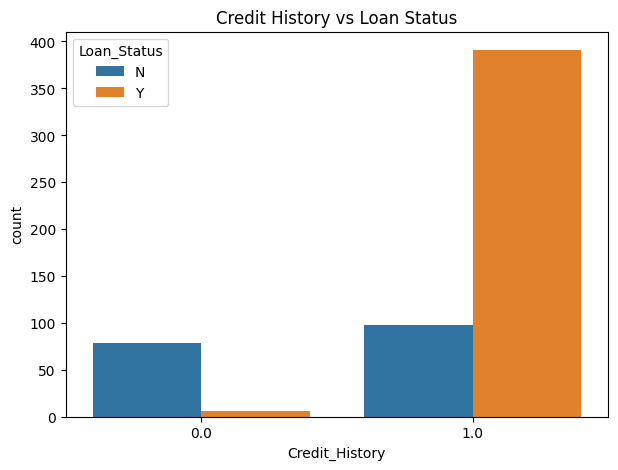

In [105]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Credit History vs Loan Status')
plt.show()

In [106]:
pd.crosstab(
    df_LoanAmount_filtered['Credit_History'],
    df_LoanAmount_filtered['Loan_Status'],
    normalize='index'
)*100

Loan_Status,N,Y
Credit_History,,
0.0,92.857143,7.142857
1.0,20.040900,79.959100


##### H2.Insight:Applicants with a positive credit history have a significantly higher loan approval rate (79.6%) compared to applicants without a positive credit history (7.9%). This suggests that credit history is one of the strongest factors associated with loan approval.

### H3. Does a higher income for the applicant increase the likelihood of loan approval?

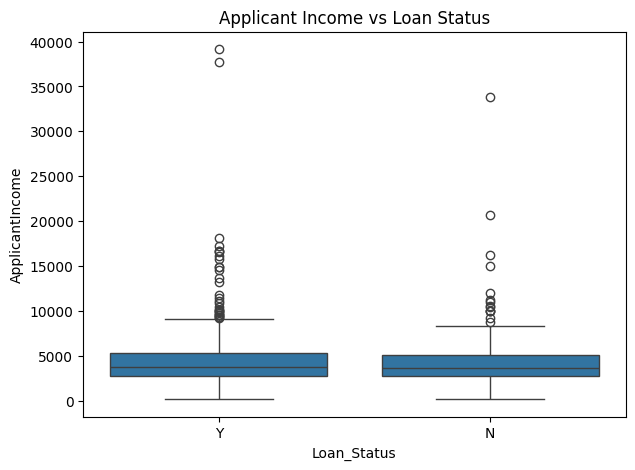

In [107]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='Loan_Status',
    y='ApplicantIncome',
    data=df_LoanAmount_filtered
)
plt.title('Applicant Income vs Loan Status')
plt.show()

In [108]:
df_LoanAmount_filtered.groupby('Loan_Status')['ApplicantIncome'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
Loan_Status,,,,
N,176,4589.380682,3597.5,3525.152539
Y,397,4676.730479,3704.0,3706.416956


##### H3.Insight: Insight:The distribution of applicant income is highly similar for approved and rejected applications.  This suggests that applicant income by itself is not a strong discriminator of loan approval in this dataset.

### H4. Are the amounts of smaller loans approved?

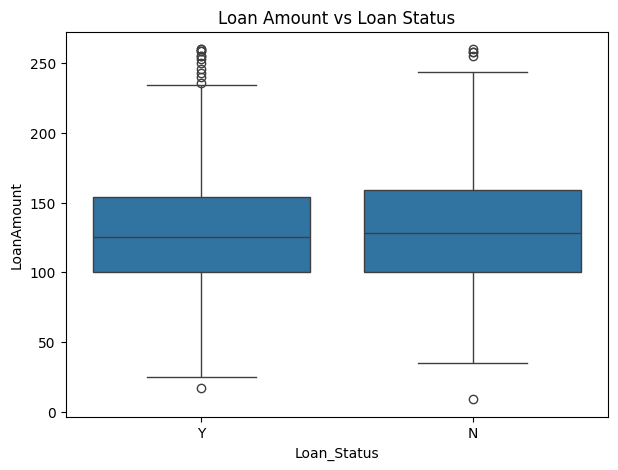

In [109]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='Loan_Status',
    y='LoanAmount',
    data=df_LoanAmount_filtered
)
plt.title('Loan Amount vs Loan Status')
plt.show()

In [110]:
df_LoanAmount_filtered.groupby('Loan_Status')['LoanAmount'].agg(
    ['count','mean','median','std']
)

,count,mean,median,std
Loan_Status,,,,
N,176,130.340909,128.0,47.362405
Y,397,127.659950,125.0,45.970211


##### H4.Insight:No strong relationship was observed

### H5. Do married applicants receive a higher approval rate?

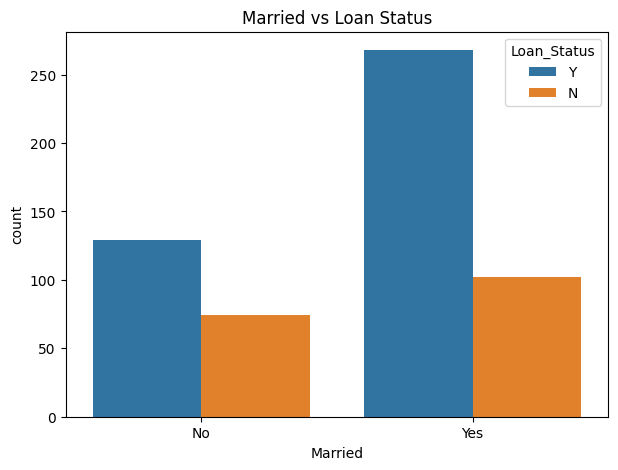

In [111]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Married',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Married vs Loan Status')
plt.show()

In [112]:
pd.crosstab(
    df['Married'],
    df['Loan_Status'],
    normalize='index'
)*100

Loan_Status,N,Y
Married,,
No,37.089202,62.910798
Yes,28.391960,71.608040


##### H5.Insight:Married applicants have a higher approval rate `(71.6%)` than unmarried applicants `(62.9%)`.

### H6. Does educational level affect loan approval?

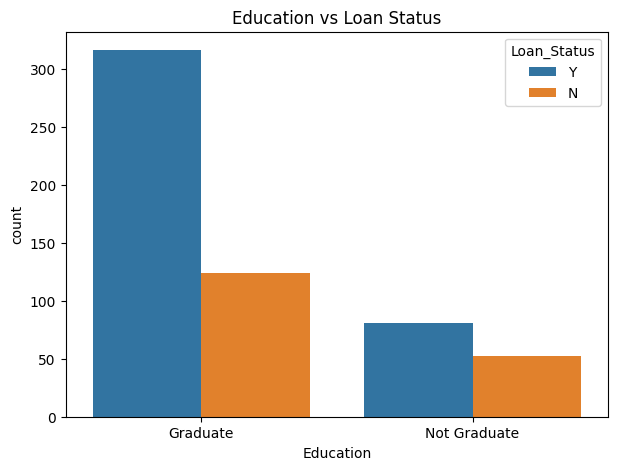

In [113]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Education',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Education vs Loan Status')
plt.show()

In [114]:
pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
)*100

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


##### H6.Insight: Graduate applicants have a higher loan approval rate (70.8%) than non-graduate applicants (61.2%), with an approximate difference of 9.6% points

### H7. Does the property area affect loan approval?

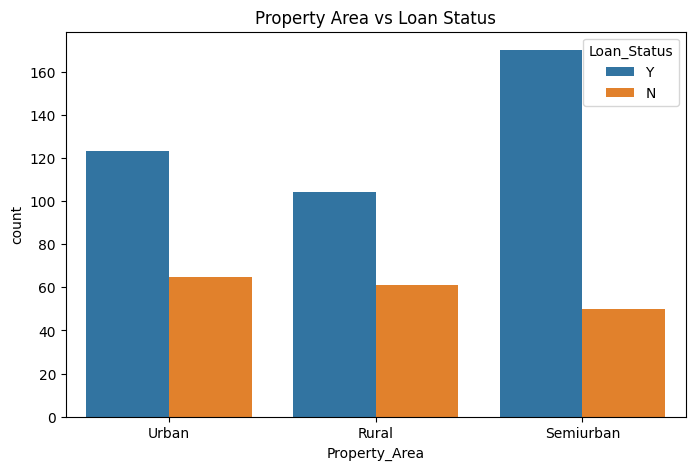

In [115]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Property Area vs Loan Status')
plt.show()

In [116]:
pd.crosstab(
    df['Property_Area'],
    df['Loan_Status'],
    normalize='index'
)*100

Loan_Status,N,Y
Property_Area,,
Rural,38.547486,61.452514
Semiurban,23.175966,76.824034
Urban,34.158416,65.841584


##### H7.Insight:Applicants from Semiurban areas have the highest loan approval rate (76.8%), followed by Urban applicants (65.8%), while Rural applicants have the lowest approval rate (61.5%).

### H8. Are applications from applicants with fewer dependents approved?

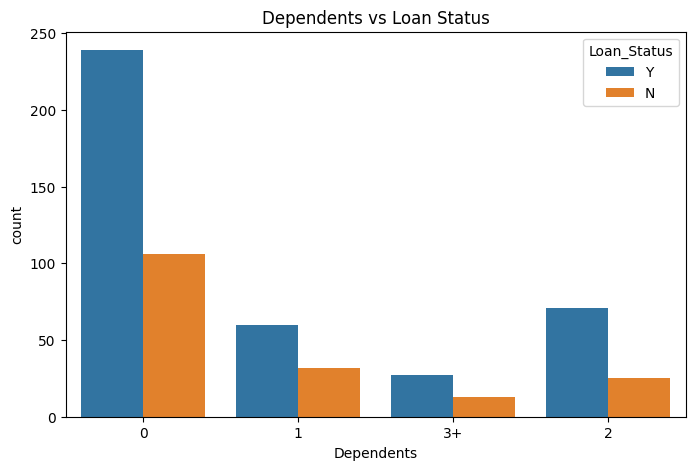

In [117]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Dependents',
    hue='Loan_Status',
    data=df_LoanAmount_filtered
)
plt.title('Dependents vs Loan Status')
plt.show()

In [118]:
pd.crosstab(
    df['Dependents'],
    df['Loan_Status'],
    normalize='index'
)*100

Loan_Status,N,Y
Dependents,,
0,31.014493,68.985507
1,35.294118,64.705882
2,24.752475,75.247525
3+,35.294118,64.705882


##### H8.Insight:Applicants with two dependents have the highest loan approval rate (75.2%), while applicants with one dependent or three or more dependents have the lowest approval rate (64.7%). Applicants with no dependents represent the largest group in the dataset, resulting in the highest number of approved applications despite a lower approval rate than the two-dependents group.

In [119]:
df_LoanAmount_filtered.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [120]:
dd = pd.crosstab(df_LoanAmount_filtered['Education'], df_LoanAmount_filtered['Loan_Status'])
dd

Loan_Status,N,Y
Education,,
Graduate,124,316
Not Graduate,52,81


####calculation of chi-square and cramer's V
### **الخطوة القادمة إنشاء function لتعمل تلقائي ومن ثم وضع الضوء الأخضر للإنتقال الى المرحلة التالية**⬇️

In [121]:
#

# جدول التقاطع
contingency = pd.crosstab(df_LoanAmount_filtered["Education"], df_LoanAmount_filtered["Loan_Status"])

# Chi-Square
chi2, p, dof, expected = chi2_contingency(contingency)

# Cramér's V
n = contingency.to_numpy().sum()
r, c = contingency.shape
cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))
print(f"column: {'eduction'}")
print(f"Chi-Square : {chi2:.4f}")
print(f"P-value    : {p:.4f}")
print(f"Cramér's V : {cramers_v:.4f}")

column: eduction
Chi-Square : 5.2170
P-value    : 0.0224
Cramér's V : 0.0954


In [122]:
df_LoanAmount_filtered.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [123]:
Categorical_columns = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area','Credit_History']


In [124]:
results = []

for col in Categorical_columns:
    observed = pd.crosstab(df_LoanAmount_filtered[col], df_LoanAmount_filtered['Loan_Status'])
    chi2, p, dof, expected = chi2_contingency(observed)

    n = observed.to_numpy().sum()
    r, c = observed.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, c) - 1)))

    results.append({
        "Column": col,
        "P-value": f"{p:.4f}",
        "Cramér's V": f"{cramers_v:.4f}"
    })

Categorical_correlation = pd.DataFrame(results)
Categorical_correlation

,Column,P-value,Cramér's V
0,Gender,0.7041,0.0159
1,Married,0.0348,0.0882
2,Dependents,0.6236,0.0554
3,Education,0.0224,0.0954
4,Self_Employed,0.7698,0.0122
5,Property_Area,0.0042,0.1382
6,Credit_History,0.0000,0.5530


*   **`Credit_History`** is the most important categorical variable.
*   **`Property_Area`** may be useful.
*   **`Married`** and **`Education`** have a weak impact.
*  **`Gender`**, **`Dependents`**, and **`Self_Employed`** may have limited importance, but this will be confirmed during model building.






## Feature Engineering


> feature extraction
>
>encoding
>
> feature selection





**Feature Extraction**  not applied, since the dataset has a small number of features.

### Encoding

In [125]:

df_LoanAmount_filtered['Gender'] = df_LoanAmount_filtered['Gender'].map({'Female': 0, 'Male': 1})
df_LoanAmount_filtered['Gender'].value_counts()

,count
Gender,
1,466
0,107


In [126]:
df_LoanAmount_filtered['Married'] = df_LoanAmount_filtered['Married'].map({'No': 0, 'Yes': 1})
df_LoanAmount_filtered['Married'].unique()

array([0, 1])

In [127]:
df_LoanAmount_filtered['Education'] = df_LoanAmount_filtered['Education'].map({'Not Graduate': 0, 'Graduate': 1})

df_LoanAmount_filtered['Education'].unique()


array([1, 0])

In [128]:
print(df_LoanAmount_filtered[['Gender', 'Married', 'Education']].head())

   Gender  Married  Education
0       1        0          1
1       1        1          1
2       1        1          1
3       1        1          0
4       1        0          1


In [129]:
 print(df_LoanAmount_filtered['Property_Area'].unique())


['Urban' 'Rural' 'Semiurban']


In [130]:
 print(df_LoanAmount_filtered['Self_Employed'].unique())

['No' 'Yes']


In [131]:
df_LoanAmount_filtered['Property_Area'] = df_LoanAmount_filtered['Property_Area'].map({'Urban':1,'Semiurban':2,'Rural':3})
df_LoanAmount_filtered['Property_Area'].unique()

array([1, 3, 2])

In [132]:
df_LoanAmount_filtered['Self_Employed'] = df_LoanAmount_filtered['Self_Employed'].map({'No':0,'Yes':1})
df_LoanAmount_filtered['Self_Employed'].unique()

array([0, 1])

In [133]:
df_LoanAmount_filtered['Loan_Status'] = df_LoanAmount_filtered['Loan_Status'].map({'N':0,'Y':1})
df_LoanAmount_filtered['Loan_Status'].unique()

array([1, 0])

In [134]:
df_LoanAmount_filtered.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,1
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,3,0
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,1
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,1
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,1


In [135]:
 df_LoanAmount_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 573 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            573 non-null    object 
 1   Gender             573 non-null    int64  
 2   Married            573 non-null    int64  
 3   Dependents         573 non-null    object 
 4   Education          573 non-null    int64  
 5   Self_Employed      573 non-null    int64  
 6   ApplicantIncome    573 non-null    int64  
 7   CoapplicantIncome  573 non-null    float64
 8   LoanAmount         573 non-null    float64
 9   Loan_Amount_Term   573 non-null    float64
 10  Credit_History     573 non-null    float64
 11  Property_Area      573 non-null    int64  
 12  Loan_Status        573 non-null    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 62.7+ KB


In [136]:
 df_LoanAmount_filtered['Dependents'].unique()

array(['0', '1', '3+', '2'], dtype=object)

In [137]:
df_LoanAmount_filtered['Dependents'] = df_LoanAmount_filtered['Dependents'].map({
    '0': 0,
    '1': 1,
    '2': 2,
    '3+': 3
})

print(df_LoanAmount_filtered['Dependents'].unique())
print(df_LoanAmount_filtered['Dependents'].dtype)

[0 1 3 2]
int64


In [138]:
# df_LoanAmount_filtered.to_excel('clean_data.xlsx', index=False)

##### **Feature Selection**

In [139]:
df_LoanAmount_filtered.shape


(573, 13)

In [140]:

df_LoanAmount_filtered = df_LoanAmount_filtered.drop(
    columns=['Loan_ID', 'Self_Employed', 'Gender', 'Dependents']
)


In [141]:
df_LoanAmount_filtered.shape


(573, 9)